# EEG-Based Alzheimer’s Disease Detection

## Objective
To detect Alzheimer’s disease using EEG signals by applying signal preprocessing techniques and deep learning models.

## 1. Data Acquisition

### 1.1 Dataset Description
- EEG dataset containing:
  - Alzheimer (AD)
  - Normal
  - MCI (optional)
- File format: `.mat`


### 1.2 Data Loading
- Load dataset using `scipy.io.loadmat()`
- Identify keys such as `AD`, `normal`

In [2]:
from scipy.io import loadmat


ad_data = loadmat('AD.mat')
normal_data = loadmat('normal.mat')

# Access main structures
ad_struct = ad_data['AD']
normal_struct = normal_data['normal']

### 1.3 Understand Data Structure
- Inspect keys inside `.mat` files  
- Identify main structures:
  - `AD`
  - `normal`
- Check type and shape of structures  
- Inspect fields inside structure:
  - `epoch`
  - `odor`
  - `noisy`
- Extract `epoch` field  
- Understand data hierarchy:
  - subjects → epochs → EEG signal  
- Inspect one subject  
- Inspect one EEG sample  
- Verify shape:
  - `(channels, time_steps)`  

In [3]:
from scipy.io import loadmat

# Load datasets
ad_data = loadmat('AD.mat')
normal_data = loadmat('normal.mat')

# Inspect keys
print("AD.mat keys:", ad_data.keys())
print("normal.mat keys:", normal_data.keys())

# Extract structures
ad_struct = ad_data['AD']
normal_struct = normal_data['normal']

# Type and shape
print("\nAD struct type:", type(ad_struct))
print("AD struct shape:", ad_struct.shape)

print("\nNormal struct type:", type(normal_struct))
print("Normal struct shape:", normal_struct.shape)

# Fields
print("\nAD struct fields:", ad_struct.dtype.names)

# Extract epoch
ad_epochs = ad_struct['epoch'][0, 0]

# Epoch info
print("\nEpoch type:", type(ad_epochs))
print("Epoch shape:", ad_epochs.shape)

# Inspect subject
subject_0 = ad_epochs[0]
print("\nSubject[0] type:", type(subject_0))
print("Number of epochs:", len(subject_0))

# Inspect sample
sample_epoch = subject_0[0]
print("\nSample epoch type:", type(sample_epoch))
print("Sample epoch shape:", sample_epoch.shape)

AD.mat keys: dict_keys(['__header__', '__version__', '__globals__', 'AD'])
normal.mat keys: dict_keys(['__header__', '__version__', '__globals__', 'normal'])

AD struct type: <class 'numpy.ndarray'>
AD struct shape: (1, 13)

Normal struct type: <class 'numpy.ndarray'>
Normal struct shape: (1, 15)

AD struct fields: ('epoch', 'odor', 'noisy')

Epoch type: <class 'numpy.ndarray'>
Epoch shape: (4, 600, 59)

Subject[0] type: <class 'numpy.ndarray'>
Number of epochs: 600

Sample epoch type: <class 'numpy.ndarray'>
Sample epoch shape: (59,)


### 1.4 Extract EEG
- Extract `epoch` field from both datasets  
- Access EEG data using:
  - `eeg_struct['epoch'][0, 0]`  
- Store:
  - `ad_epochs`
  - `normal_epochs`
- Each contains:
  - subjects → epochs → EEG signal  

In [4]:
# Extract EEG epochs
ad_epochs = ad_struct['epoch'][0, 0]
normal_epochs = normal_struct['epoch'][0, 0]

# Basic check
print("AD epochs shape:", ad_epochs.shape)
print("Normal epochs shape:", normal_epochs.shape)

AD epochs shape: (4, 600, 59)
Normal epochs shape: (4, 600, 119)


### 1.5 Inspect Sample
- Select one subject from dataset  
- Select one epoch from subject  
- Inspect EEG sample  
- Check:
  - Type  
  - Shape `(channels, time_steps)`  
- View a small portion of data  

In [5]:
# Select one subject and one epoch
ad_subject_0 = ad_epochs[0]
ad_sample = ad_subject_0[0]

# Handle nested structure (MATLAB cell inside numpy object)
while isinstance(ad_sample, (list, tuple)) or ad_sample.dtype == object:
    ad_sample = ad_sample[0]

# Convert to numpy array
import numpy as np
ad_sample = np.array(ad_sample)

# Inspect sample
print("Sample type:", type(ad_sample))
print("Sample shape:", ad_sample.shape)

# View first few values safely
if ad_sample.ndim == 2:
    print("\nSample data (first 5 values):")
    print(ad_sample[:, :5])
else:
    print("\nSample data (first 5 values):")
    print(ad_sample[:5])

Sample type: <class 'numpy.ndarray'>
Sample shape: (59,)

Sample data (first 5 values):
[ 69.81173706  69.89250183 -34.19271851   0.49149582  -9.8884697 ]


### 1.6 Validate Data
- Iterate through samples  
- Ensure EEG data is numeric  
- Check for empty or invalid samples  
- Verify consistent structure  

In [6]:
import numpy as np

valid = True

for subject in ad_epochs:
    for epoch in subject:
        sample = epoch
        while isinstance(sample, (list, tuple)) or (hasattr(sample, "dtype") and sample.dtype == object):
            sample = sample[0]
        sample = np.array(sample)
        if sample.size == 0 or not np.issubdtype(sample.dtype, np.number):
            valid = False
            break

print("AD data valid:", valid)

valid = True

for subject in normal_epochs:
    for epoch in subject:
        sample = epoch
        while isinstance(sample, (list, tuple)) or (hasattr(sample, "dtype") and sample.dtype == object):
            sample = sample[0]
        sample = np.array(sample)
        if sample.size == 0 or not np.issubdtype(sample.dtype, np.number):
            valid = False
            break

print("Normal data valid:", valid)

AD data valid: True
Normal data valid: True


### 2.1 Extract EEG Epochs
- Iterate through subjects  
- Iterate through epochs inside each subject  
- Extract EEG signals  
- Handle nested MATLAB structure  
- Store all EEG samples in a list  

In [7]:
import numpy as np

ad_X = []

for subject in ad_epochs:
    for epoch in subject:
        sample = epoch
        while isinstance(sample, (list, tuple)) or (hasattr(sample, "dtype") and sample.dtype == object):
            sample = sample[0]
        sample = np.array(sample)
        ad_X.append(sample)

normal_X = []

for subject in normal_epochs:
    for epoch in subject:
        sample = epoch
        while isinstance(sample, (list, tuple)) or (hasattr(sample, "dtype") and sample.dtype == object):
            sample = sample[0]
        sample = np.array(sample)
        normal_X.append(sample)

print("AD samples:", len(ad_X))
print("Normal samples:", len(normal_X))

AD samples: 2400
Normal samples: 2400


### 2.2 Combine AD + Normal
- Combine extracted EEG samples  
- Create single dataset `X`  
- Preserve order: AD first, then Normal  

In [8]:
X = ad_X + normal_X

print("Total samples:", len(X))

Total samples: 4800


### 2.3 Label Encoding
- Assign labels:
  - AD → 1
  - Normal → 0  
- Create label array `y`  

In [9]:
import numpy as np

y_ad = [1] * len(ad_X)
y_normal = [0] * len(normal_X)

y = np.array(y_ad + y_normal)

print("Labels shape:", y.shape)

Labels shape: (4800,)


### 2.4 Handle Variable-Length Signals
- Find minimum time length across all samples  
- Crop all samples to same length  
- Ensure uniform shape for model input  

In [10]:
min_len = min(sample.shape[-1] for sample in X)

X_cropped = [sample[..., :min_len] for sample in X]

print("Minimum length:", min_len)
print("Sample shape after cropping:", X_cropped[0].shape)

Minimum length: 59
Sample shape after cropping: (59,)


### 2.5 Final Dataset Creation (X, y)
- Convert list of samples into NumPy array  
- Ensure uniform shape  
- Prepare final dataset `(X, y)` for modeling  

In [11]:
import numpy as np

X = np.array(X_cropped)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4800, 59)
y shape: (4800,)


### 3.1 Bandpass Filter (1–40 Hz)
- Apply bandpass filter to EEG signals  
- Frequency range: 0.5–40 Hz  
- Process each sample  

In [12]:
from scipy.signal import butter, filtfilt
import numpy as np

fs = 256

def bandpass(data, low=0.5, high=40, fs=256, order=5):
    nyq = 0.5 * fs
    b, a = butter(order, [low/nyq, high/nyq], btype='band')
    return filtfilt(b, a, data)

sample_before = X[0].copy()
sample_after = bandpass(X[0])

X_filtered = np.array([bandpass(sample) for sample in X])

print("Before → mean:", np.mean(sample_before), "std:", np.std(sample_before))
print("After  → mean:", np.mean(sample_after), "std:", np.std(sample_after))

Before → mean: 7.698982276653839 std: 126.76928903056279
After  → mean: 42.09482216348912 std: 82.9207306338142


### 3.2 Notch Filter (50 Hz)
- Remove powerline noise  
- Frequency: 50 Hz  
- Apply to each sample  

In [13]:
from scipy.signal import iirnotch, filtfilt
import numpy as np

fs = 256
f0 = 50
Q = 30

b, a = iirnotch(f0/(fs/2), Q)

sample_before = X_filtered[0].copy()
sample_after = filtfilt(b, a, X_filtered[0])

X_notched = np.array([filtfilt(b, a, sample) for sample in X_filtered])

print("Before → mean:", np.mean(sample_before), "std:", np.std(sample_before))
print("After  → mean:", np.mean(sample_after), "std:", np.std(sample_after))

Before → mean: 42.09482216348912 std: 82.9207306338142
After  → mean: 42.09310770843771 std: 82.83134979039191


### 3.3 Normalization
- Normalize EEG signals  
- Apply per sample  
- Scale values to standard range  

In [14]:
import numpy as np

sample_before = X_notched[0].copy()
sample_after = (sample_before - np.mean(sample_before)) / np.std(sample_before)

X_norm = np.array([(sample - np.mean(sample)) / np.std(sample) for sample in X_notched])

print("Before → mean:", np.mean(sample_before), "std:", np.std(sample_before))
print("After  → mean:", np.mean(sample_after), "std:", np.std(sample_after))

Before → mean: 42.09310770843771 std: 82.83134979039191
After  → mean: 0.0 std: 1.0


### 4.1 FFT
- Apply Fast Fourier Transform  
- Convert signal to frequency domain  
- Compute magnitude spectrum  
- Verify change using mean and standard deviation  

In [15]:
import numpy as np

sample_before = X_norm[0].copy()
sample_after = np.abs(np.fft.fft(sample_before))

X_fft = np.array([np.abs(np.fft.fft(sample)) for sample in X_norm])

print("Before → mean:", np.mean(sample_before), "std:", np.std(sample_before))
print("After  → mean:", np.mean(sample_after), "std:", np.std(sample_after))

Before → mean: 0.0 std: 1.0
After  → mean: 4.453455865337619 std: 6.258332913443479


### 4.2 Spectrogram
- Convert EEG signal into time-frequency representation  
- Use spectrogram transformation  
- Verify change using mean and standard deviation  

In [16]:
from scipy.signal import spectrogram
import numpy as np

fs = 256

def get_spec(sample):
    f, t, Sxx = spectrogram(sample, fs=fs, nperseg=16, noverlap=8)
    return Sxx

sample_before = X_norm[0]
sample_after = get_spec(sample_before)

X_spec = np.array([get_spec(sample) for sample in X_norm])

print("Before shape:", sample_before.shape)
print("After shape:", sample_after.shape)

Before shape: (59,)
After shape: (9, 6)


### 5.1 Train-Test Split
- Split dataset into training and testing sets  
- Maintain labels alignment  

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_spec, y, test_size=0.2, random_state=42, stratify=y
)

print("Train samples:", len(X_train))
print("Test samples:", len(X_test))

Train samples: 3840
Test samples: 960


### 5.2 CNN Model
- Build CNN model for classification  
- Input: spectrogram  
- Output: binary classification  

In [18]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(
    X_spec, y, test_size=0.2, random_state=42, stratify=y
)

X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

model = models.Sequential([
    layers.Input(shape=X_train.shape[1:]),
    layers.Conv2D(32, (2,2), activation='relu'),
    layers.Conv2D(64, (2,2), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 8, 5, 32)       │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 4, 64)       │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1792)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       114,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123,233 (481.38 KB)

 Trainable params: 123,233 (481.38 KB)

 Non-trainable params: 0 (0.00 B)

### 6.1 Training
- Train CNN model  
- Use training data  
- Validate on test data  

In [19]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6328 - loss: 0.6320 - val_accuracy: 0.6823 - val_loss: 0.5806
Epoch 2/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6846 - loss: 0.5571 - val_accuracy: 0.7323 - val_loss: 0.5016
Epoch 3/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7206 - loss: 0.5192 - val_accuracy: 0.7781 - val_loss: 0.4595
Epoch 4/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7547 - loss: 0.4828 - val_accuracy: 0.7948 - val_loss: 0.4442
Epoch 5/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7734 - loss: 0.4652 - val_accuracy: 0.8250 - val_loss: 0.3973
Epoch 6/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7937 - loss: 0.4239 - val_accuracy: 0.8417 - val_loss: 0.3755
Epoch 7/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8055 - loss: 0.4004 - val_accuracy: 0.8490 - val_loss: 0.3589
Epoch 8/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8313 - loss: 0.3710 - val_accuracy: 

### 6.2 Metrics
- Evaluate model performance on test data  
- Compute accuracy and loss  

In [20]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8531 - loss: 0.3001
Test Loss: 0.30006441473960876
Test Accuracy: 0.8531249761581421


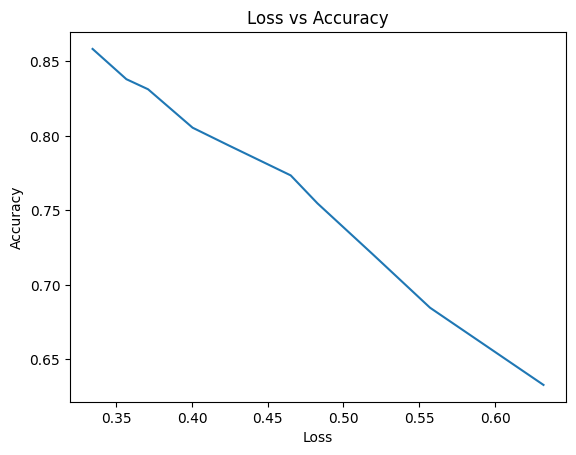

In [21]:
import matplotlib.pyplot as plt

history_dict = history.history

plt.figure()
plt.plot(history_dict['loss'], history_dict['accuracy'])
plt.xlabel('Loss')
plt.ylabel('Accuracy')
plt.title('Loss vs Accuracy')
plt.show()